In [1]:
from google.colab import files
uploaded = files.upload()

Saving sarcoidosis_labels_final.csv to sarcoidosis_labels_final.csv


In [2]:
from google.colab import files
uploaded = files.upload()

Saving sarcoidosis_expression_final.csv to sarcoidosis_expression_final.csv


In [3]:
import pandas as pd
import numpy as np

X_all = pd.read_csv("sarcoidosis_expression_final.csv", index_col=0)
y_all = pd.read_csv("sarcoidosis_labels_final.csv", index_col=0).iloc[:, 0]

print(X_all.shape)
print(y_all.value_counts())

(398, 16622)
0
0    229
1    169
Name: count, dtype: int64


In [4]:
groups = np.array(
    ["GSE18781"] * 37 +
    ["GSE42834"] * 251 +
    ["GSE83456"] * 110
)

print(len(groups))

398


In [5]:
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [6]:
def evaluate_model(name, pipeline, X, y, groups):
    logo = LeaveOneGroupOut()

    pred = cross_val_predict(
        pipeline,
        X,
        y,
        groups=groups,
        cv=logo,
        method="predict"
    )

    prob = None
    try:
        prob = cross_val_predict(
            pipeline,
            X,
            y,
            groups=groups,
            cv=logo,
            method="predict_proba"
        )[:, 1]
    except:
        pass

    acc = accuracy_score(y, pred)

    print(f"\n{name}")
    print("-" * 50)
    print("Accuracy:", round(acc, 4))
    print("Confusion Matrix:")
    print(confusion_matrix(y, pred))
    print("\nClassification Report:")
    print(classification_report(y, pred, digits=3))

    if prob is not None:
        auc = roc_auc_score(y, prob)
        print("ROC-AUC:", round(auc, 4))
    else:
        auc = None
        print("ROC-AUC: not available")

    return {
        "name": name,
        "pred": pred,
        "prob": prob,
        "accuracy": acc,
        "auc": auc
    }

In [7]:
k_features = 1000

logreg_pipe = Pipeline([
    ("var", VarianceThreshold()),
    ("scale", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif, k=k_features)),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42))
])

rf_pipe = Pipeline([
    ("var", VarianceThreshold()),
    ("select", SelectKBest(score_func=f_classif, k=k_features)),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

svm_pipe = Pipeline([
    ("var", VarianceThreshold()),
    ("scale", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif, k=k_features)),
    ("model", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
])

knn_pipe = Pipeline([
    ("var", VarianceThreshold()),
    ("scale", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif, k=500)),
    ("model", KNeighborsClassifier(n_neighbors=7))
])

nb_pipe = Pipeline([
    ("var", VarianceThreshold()),
    ("select", SelectKBest(score_func=f_classif, k=1000)),
    ("model", GaussianNB())
])

gb_pipe = Pipeline([
    ("var", VarianceThreshold()),
    ("select", SelectKBest(score_func=f_classif, k=1000)),
    ("model", GradientBoostingClassifier(random_state=42))
])

In [8]:
results = []

results.append(evaluate_model("Logistic Regression", logreg_pipe, X_all, y_all, groups))
results.append(evaluate_model("Random Forest", rf_pipe, X_all, y_all, groups))
results.append(evaluate_model("SVM", svm_pipe, X_all, y_all, groups))
results.append(evaluate_model("KNN", knn_pipe, X_all, y_all, groups))
results.append(evaluate_model("Naive Bayes", nb_pipe, X_all, y_all, groups))
results.append(evaluate_model("Gradient Boosting", gb_pipe, X_all, y_all, groups))


Logistic Regression
--------------------------------------------------
Accuracy: 0.7161
Confusion Matrix:
[[139  90]
 [ 23 146]]

Classification Report:
              precision    recall  f1-score   support

           0      0.858     0.607     0.711       229
           1      0.619     0.864     0.721       169

    accuracy                          0.716       398
   macro avg      0.738     0.735     0.716       398
weighted avg      0.756     0.716     0.715       398

ROC-AUC: 0.799

Random Forest
--------------------------------------------------
Accuracy: 0.7613
Confusion Matrix:
[[184  45]
 [ 50 119]]

Classification Report:
              precision    recall  f1-score   support

           0      0.786     0.803     0.795       229
           1      0.726     0.704     0.715       169

    accuracy                          0.761       398
   macro avg      0.756     0.754     0.755       398
weighted avg      0.761     0.761     0.761       398

ROC-AUC: 0.8504

SVM
--------

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Gradient Boosting
--------------------------------------------------
Accuracy: 0.6608
Confusion Matrix:
[[133  96]
 [ 39 130]]

Classification Report:
              precision    recall  f1-score   support

           0      0.773     0.581     0.663       229
           1      0.575     0.769     0.658       169

    accuracy                          0.661       398
   macro avg      0.674     0.675     0.661       398
weighted avg      0.689     0.661     0.661       398

ROC-AUC: 0.7331


In [9]:
summary_df = pd.DataFrame({
    "Model": [r["name"] for r in results],
    "Accuracy": [r["accuracy"] for r in results],
    "ROC_AUC": [r["auc"] for r in results]
})

summary_df = summary_df.sort_values(by="ROC_AUC", ascending=False)
summary_df

,Model,Accuracy,ROC_AUC
1,Random Forest,0.761307,0.850366
2,SVM,0.736181,0.848428
0,Logistic Regression,0.716080,0.798972
5,Gradient Boosting,0.660804,0.733146
3,KNN,0.623116,0.674569
4,Naive Bayes,0.424623,0.500000


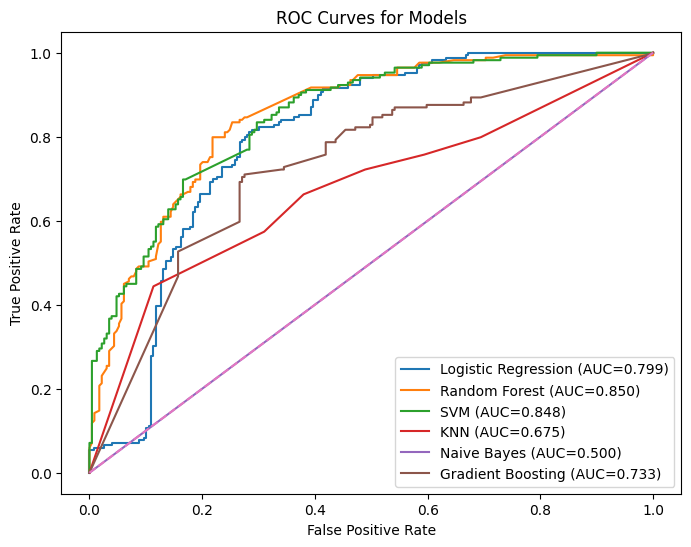

In [10]:
plt.figure(figsize=(8,6))

for r in results:
    if r["prob"] is not None:
        fpr, tpr, _ = roc_curve(y_all, r["prob"])
        auc = roc_auc_score(y_all, r["prob"])
        plt.plot(fpr, tpr, label=f"{r['name']} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Models")
plt.legend()
plt.show()

In [11]:
rf_pipe.fit(X_all, y_all)

rf_model = rf_pipe.named_steps["model"]
selector = rf_pipe.named_steps["select"]

selected_genes = X_all.columns[selector.get_support()]

importance = pd.Series(rf_model.feature_importances_, index=selected_genes)

top_genes = importance.sort_values(ascending=False).head(20)

top_genes

,0
LEF1,0.016964
FCGR1A,0.015340
FAM102A,0.014411
GBP5,0.013386
ANKRD22,0.012872
FCGR1B,0.012530
GBP4,0.012324
LRRN3,0.011356
NOSIP,0.011053
LHFPL2,0.010698


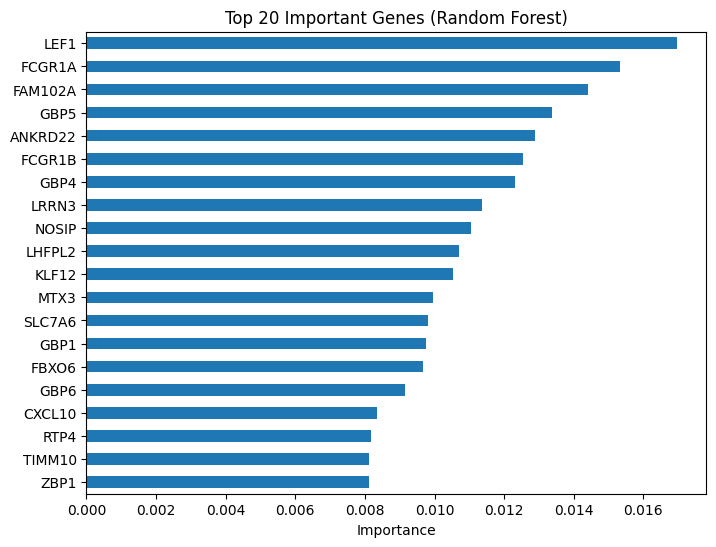

In [12]:
top_genes.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Top 20 Important Genes (Random Forest)")
plt.xlabel("Importance")
plt.show()

In [13]:
%whos

Variable                     Type                      Data/Info
----------------------------------------------------------------
GaussianNB                   ABCMeta                   <class 'sklearn.naive_bayes.GaussianNB'>
GradientBoostingClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>dientBoostingClassifier'>
KNeighborsClassifier         ABCMeta                   <class 'sklearn.neighbors<...>on.KNeighborsClassifier'>
LeaveOneGroupOut             ABCMeta                   <class 'sklearn.model_sel<...>_split.LeaveOneGroupOut'>
LogisticRegression           type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
Pipeline                     ABCMeta                   <class 'sklearn.pipeline.Pipeline'>
RandomForestClassifier       ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
SVC                          ABCMeta                   <class 'sklearn.svm._classes.SVC'>
SelectKBest                  ABCMeta  

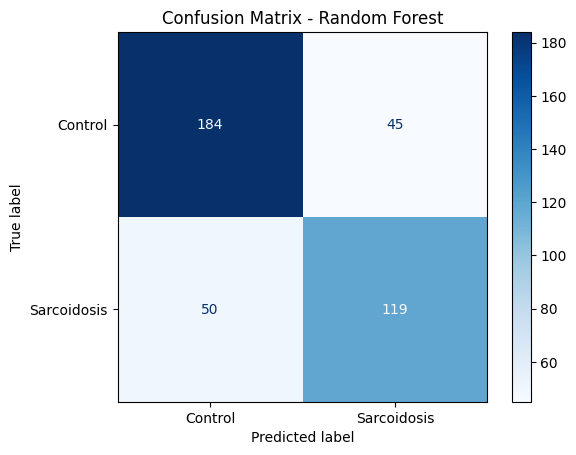

In [14]:
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Leave-one-cohort-out predictions
logo = LeaveOneGroupOut()
y_pred = cross_val_predict(rf_pipe, X_all, y_all, cv=logo.split(X_all, y_all, groups=groups))

# Confusion matrix
cm = confusion_matrix(y_all, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Control", "Sarcoidosis"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.savefig("confusion_matrix.png", bbox_inches="tight", dpi=300)
plt.show()

In [15]:
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict

logo = LeaveOneGroupOut()

y_pred = cross_val_predict(
    rf_pipe,
    X_all,
    y_all,
    cv=logo.split(X_all, y_all, groups=groups)
)

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_all, y_pred)
recall = recall_score(y_all, y_pred)
f1 = f1_score(y_all, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.725609756097561
Recall: 0.7041420118343196
F1-score: 0.7147147147147147


In [17]:
X_var = rf_pipe.named_steps['var'].fit_transform(X_all)
print(X_var.shape)

(398, 16622)


In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

full_metrics = []

for r in results:
    y_pred = r["pred"]

    precision = precision_score(y_all, y_pred, zero_division=0)
    recall = recall_score(y_all, y_pred, zero_division=0)
    f1 = f1_score(y_all, y_pred, zero_division=0)

    full_metrics.append({
        "Model": r["name"],
        "Accuracy": r["accuracy"],
        "ROC_AUC": r["auc"],
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

import pandas as pd
full_df = pd.DataFrame(full_metrics)

print(full_df)

                 Model  Accuracy   ROC_AUC  Precision    Recall        F1
0  Logistic Regression  0.716080  0.798972   0.618644  0.863905  0.720988
1        Random Forest  0.761307  0.850366   0.725610  0.704142  0.714715
2                  SVM  0.736181  0.848428   0.640351  0.863905  0.735516
3                  KNN  0.623116  0.674569   0.544601  0.686391  0.607330
4          Naive Bayes  0.424623  0.500000   0.424623  1.000000  0.596120
5    Gradient Boosting  0.660804  0.733146   0.575221  0.769231  0.658228


In [20]:
import pandas as pd

pd.Series(y_all).map({0:"Control", 1:"Sarcoidosis"}).value_counts()

,count
0,
Control,229
Sarcoidosis,169


In [21]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PC1': X_pca[:,0],
    'PC2': X_pca[:,1],
    'Disease': y_all,
    'Cohort': groups
})

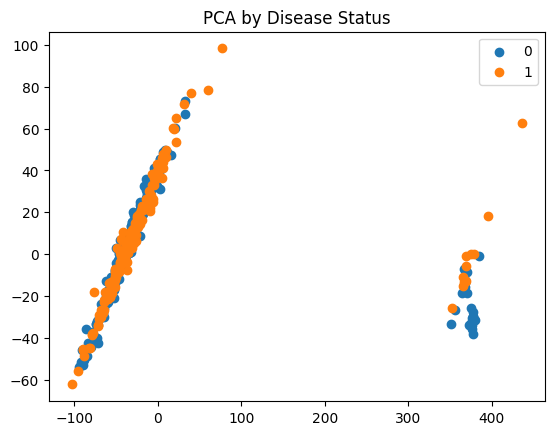

In [22]:
import matplotlib.pyplot as plt

for label in pca_df['Disease'].unique():
    subset = pca_df[pca_df['Disease'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], label=label)

plt.legend()
plt.title("PCA by Disease Status")
plt.show()

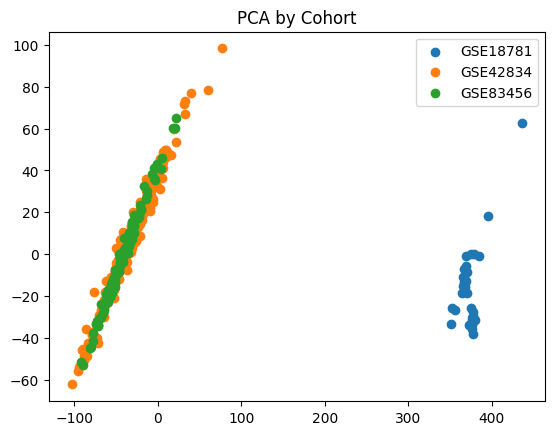

In [23]:
for cohort in pca_df['Cohort'].unique():
    subset = pca_df[pca_df['Cohort'] == cohort]
    plt.scatter(subset['PC1'], subset['PC2'], label=cohort)

plt.legend()
plt.title("PCA by Cohort")
plt.show()